In [1]:
SQLITE_PATH = './../data/dbfinal_2.sqlite3'
CSV_PATH = './../data/final_data_3/ml_final_data_test.csv'
MODEL_PATH = './../stored_models/model_1_black_pieces.h5'
ML_DATA_TEST_PATH = './../data/final_data_3/ml_final_data_test.csv'
import sqlite3
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.python.client import device_lib
import os
import sys
from collections import Counter
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input, BatchNormalization, Activation, Add, LeakyReLU, Concatenate, Multiply
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras import layers
from tensorflow.keras.applications import InceptionResNetV2, VGG16, MobileNetV2
from tensorflow.keras.utils import to_categorical
import keras.backend as K
from PIL import Image
import requests
import zipfile

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output as cls
from keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
import pandas as pd
import PIL

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import statistics
import ast
import json
import statistics

import glob
import cv2
from PIL import Image
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

import chess
from chess.engine import Mate, Cp

module_path = os.path.abspath(os.path.join('..', 'utils'))
if module_path not in sys.path:
    sys.path.append(module_path)

from utils2 import DataGenerator, plot_graph, bar_plot, two_bar_plot, StepwiseLogger, decode_pos

def execute_query(db, query):
    conn = sqlite3.connect(db)
    cur = conn.cursor()
    cur.execute(query)
    rows = cur.fetchall()
    conn.commit()
    conn.close()
    return rows

In [4]:
data = pd.DataFrame(execute_query(SQLITE_PATH, "SELECT * FROM moves;"))
data.rename(columns={0:'move', 1:'cp_loss', 2:'is_blunder_cp', 3:'white_active', 4:'board_pgn', 5:'is_check'}, inplace=True)

In [5]:
data

,move,cp_loss,is_blunder_cp,white_active,board_pgn,is_check
0,e2e4,-0.02,0,1,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,0
1,e7e6,0.00,0,0,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,0
2,g1f3,0.03,0,1,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,0
3,a7a6,0.39,0,0,rnbqkbnr/pppp1ppp/4p3/8/4P3/5N2/PPPP1PPP/RNBQK...,0
4,d2d4,0.21,0,1,rnbqkbnr/1ppp1ppp/p3p3/8/4P3/5N2/PPPP1PPP/RNBQ...,0
...,...,...,...,...,...,...
9581621,g1g2,1.89,0,1,2Q5/p3kpp1/2p2b1p/3p4/q2P2P1/P2BPn1P/5P2/R1R3K...,1
9581622,f3h4,3.35,1,0,2Q5/p3kpp1/2p2b1p/3p4/q2P2P1/P2BPn1P/5PK1/R1R5...,0
9581623,g2g3,2.06,1,1,2Q5/p3kpp1/2p2b1p/3p4/q2P2Pn/P2BP2P/5PK1/R1R5 ...,1
9581624,h4g6,inf,1,0,2Q5/p3kpp1/2p2b1p/3p4/q2P2Pn/P2BP1KP/5P2/R1R5 ...,0


In [6]:
value_counts = data['move'].value_counts()

In [7]:
len(value_counts)

1922

In [25]:
special_moves = [k for k in value_counts.keys() if len(k) > 4]
len(special_moves)

130

In [34]:
sum(value_counts[special_moves])/len(data)*100

0.16114175193229208

In [8]:
bins = [0, 10, 100, 1000, 10000, 100000]
labels = ['0-10', '10-10\u00b2', '10\u00b2-10\N{SUPERSCRIPT THREE}', '10\N{SUPERSCRIPT THREE}-10\N{SUPERSCRIPT FOUR}', '+10\N{SUPERSCRIPT FOUR}']
frequency_bins = pd.cut(value_counts, bins=bins, labels=labels, right=True)
frequency_bins

move
g1f3      NaN
g8f6      NaN
d2d4      NaN
e1g1      NaN
e2e4      NaN
         ... 
d2d1b    0-10
d2e1r    0-10
d2c1n    0-10
f2g1r    0-10
e2f1n    0-10
Name: count, Length: 1922, dtype: category
Categories (5, object): ['0-10' < '10-10²' < '10²-10³' < '10³-10⁴' < '+10⁴']

In [9]:
frequency_bin_counts = frequency_bins.value_counts().sort_index()
frequency_bin_counts

count
0-10         66
10-10²       59
10²-10³     532
10³-10⁴    1037
+10⁴        220
Name: count, dtype: int64

<Axes: xlabel='move'>

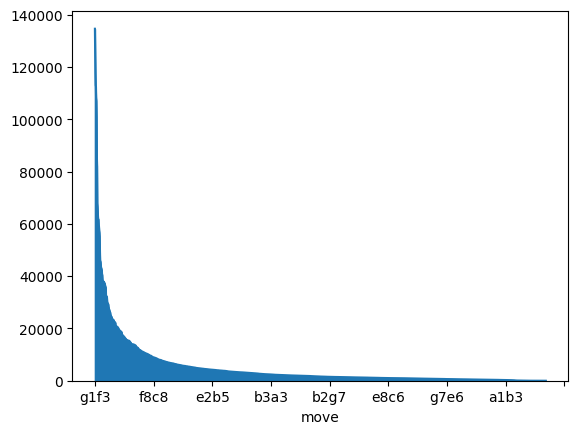

In [10]:
value_counts.plot(kind='area')

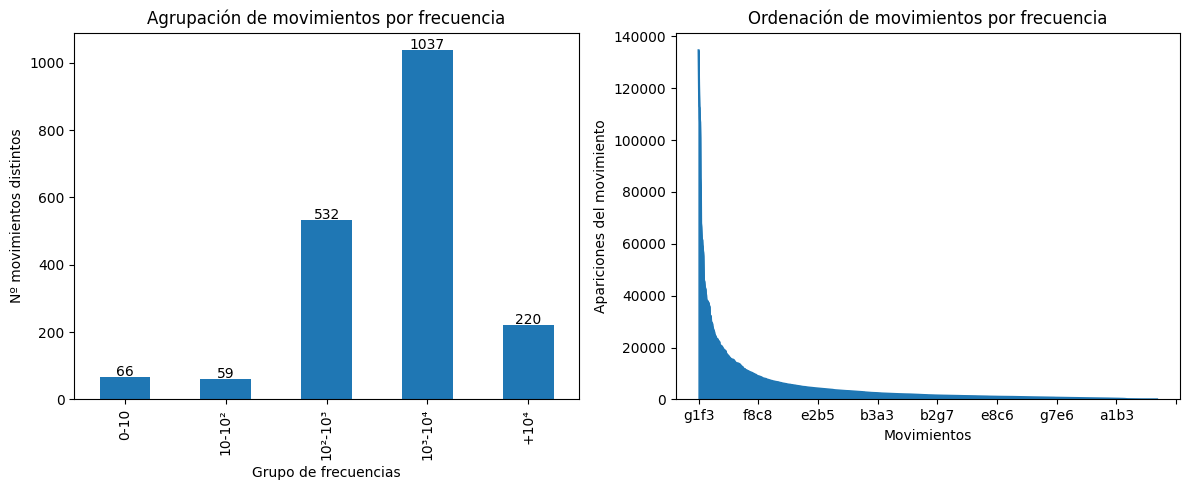

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bar_plot = frequency_bin_counts.plot(kind='bar', ax=axes[0])
axes[0].set_xlabel('Grupo de frecuencias')
axes[0].set_ylabel('Nº movimientos distintos')
axes[0].set_title('Agrupación de movimientos por frecuencia')

value_counts.plot(kind='area', ax=axes[1])
axes[1].set_xlabel('Movimientos')
axes[1].set_ylabel('Apariciones del movimiento')
axes[1].set_title('Ordenación de movimientos por frecuencia')
axes[1].set_yscale('linear')

for bar in bar_plot.patches:
    bar_plot.annotate(format(bar.get_height(), '.0f'),
                      (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                      ha='center', va='center', xytext=(0, 4),
                      textcoords='offset points')
    
plt.tight_layout()
plt.show()

In [12]:
moves_needed = 0
total = 0 
for value in value_counts:
    moves_needed += 1
    total += value
    if total >= sum(value_counts)*50/100:
        print(moves_needed)
        break

138


In [13]:
sum(value_counts)

9581626

In [14]:
value_counts.median()

1605.0

In [16]:
sum(value_counts[:10])

1086222

In [17]:
is_blunder_value_counts = data['is_blunder_cp'].value_counts()
is_blunder_value_counts

is_blunder_cp
0    8555592
1    1026034
Name: count, dtype: int64

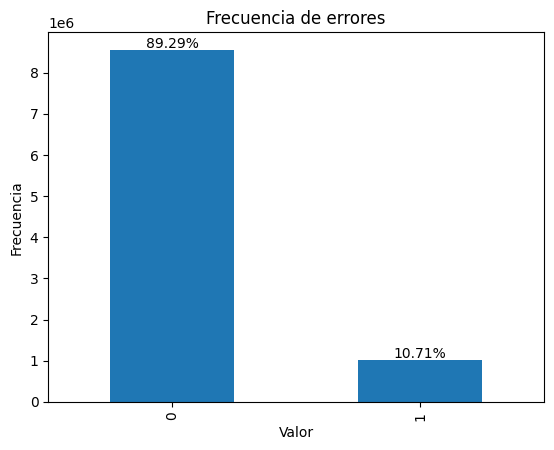

In [18]:
bar_plot = is_blunder_value_counts.plot(kind='bar')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.title('Frecuencia de errores')

for bar in bar_plot.patches:
    bar_plot.annotate(format((bar.get_height()/len(data))*100, '.2f') + '%',
                      (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                      ha='center', va='center', xytext=(0, 4),
                      textcoords='offset points')

In [47]:
data2 = pd.read_csv(CSV_PATH)

In [3]:
initial_value_counts = data2['initial_pos'].value_counts()
initial_value_counts

initial_pos
e7    29252
d7    28739
f1    27920
f8    27882
e2    27768
      ...  
a6     5420
h3     5350
h8     5146
a3     4739
h1     4692
Name: count, Length: 64, dtype: int64

In [4]:
def bar_plot(x, y, title, xlabel, ylabel):
    plt.figure(figsize=(15, 6))
    plt.bar(x, y)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(x, [f'{i}' for i in x])
    plt.tight_layout()
    plt.show()

In [5]:
def sort_value_counts(value_counts):
    sorted_value_counts = []
    values = []
    for row in ['8','7','6','5','4','3','2','1']:
        for column in ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']:
            values.append(column+row)
            sorted_value_counts.append(value_counts[column + row])
    return values, sorted_value_counts

In [6]:
values, sorted_value_counts = sort_value_counts(initial_value_counts)

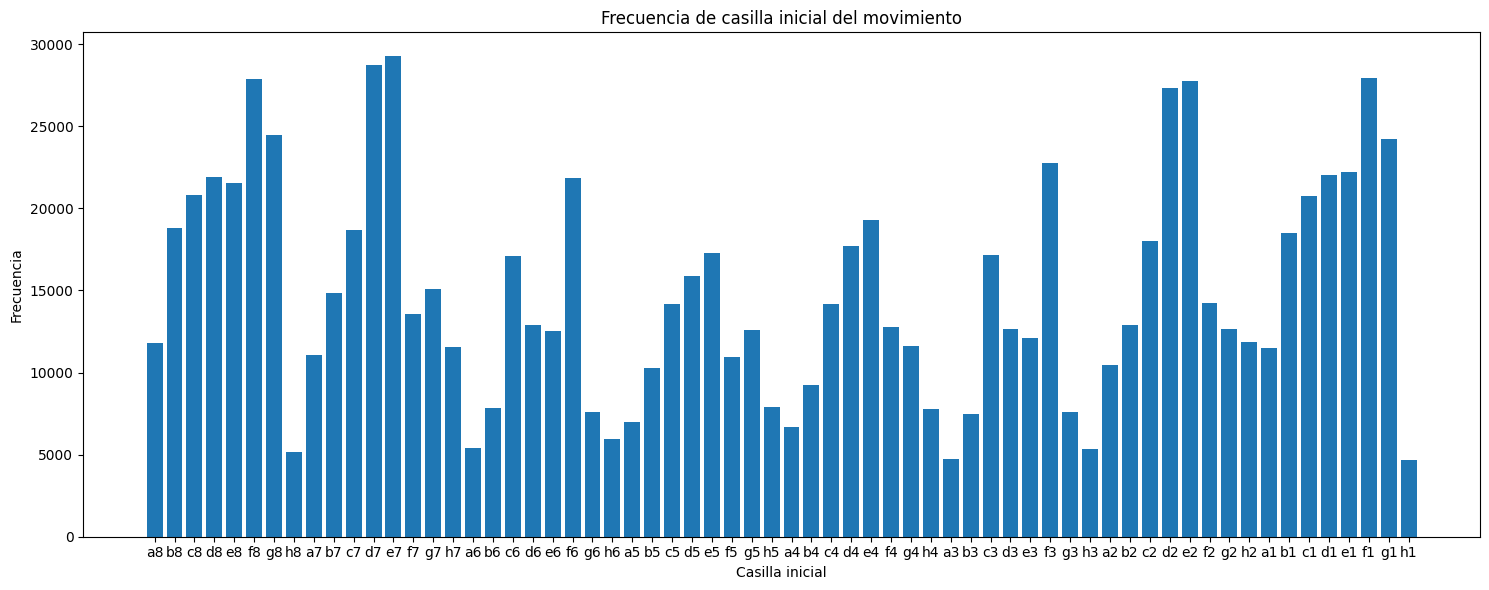

In [7]:
bar_plot(values, sorted_value_counts, "Frecuencia de casilla inicial del movimiento", "Casilla inicial", "Frecuencia")

In [8]:
final_value_counts = data2['final_pos'].value_counts()
values, sorted_value_counts = sort_value_counts(final_value_counts)

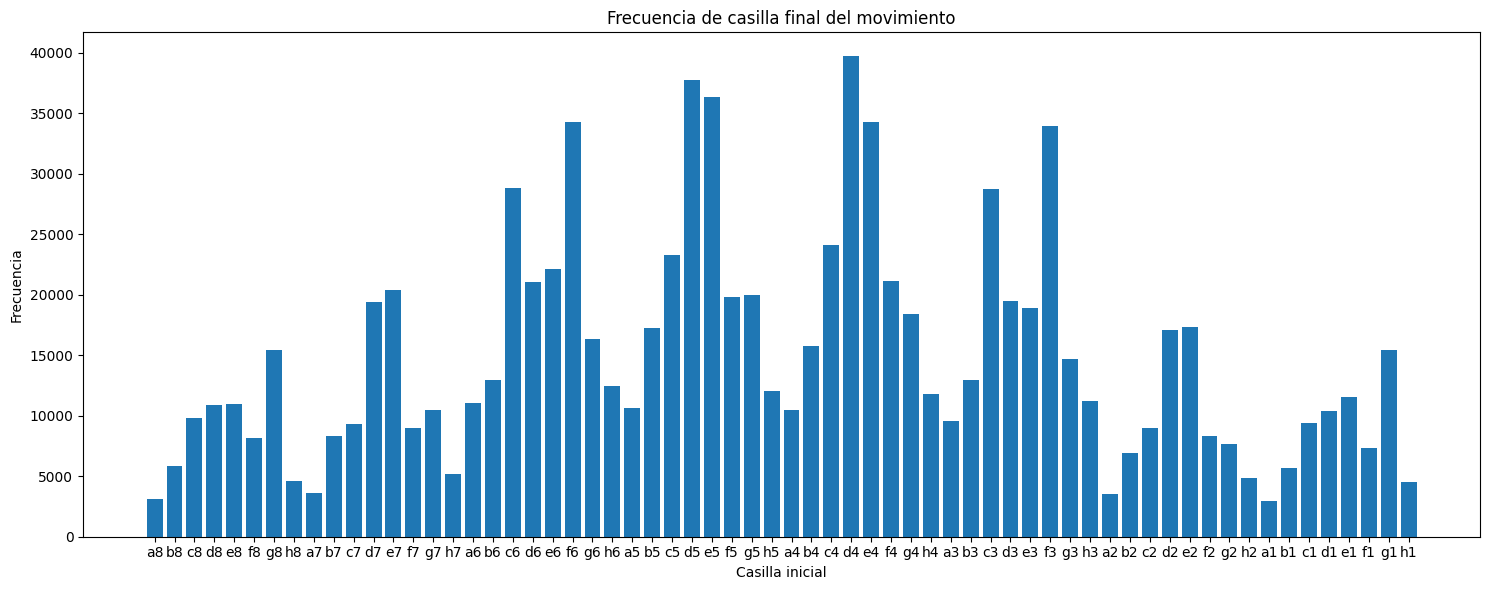

In [9]:
bar_plot(values, sorted_value_counts, "Frecuencia de casilla final del movimiento", "Casilla inicial", "Frecuencia")

## Evaluación de modelo final

In [2]:
model = load_model(MODEL_PATH)

In [11]:
read_size = 524288
batch_size = 64
num_classes = 64
test_data_generator = DataGenerator(ML_DATA_TEST_PATH, read_size, batch_size, num_classes, 958163, sparse_single_and_partial=True, shuffle=False)

In [12]:
model.evaluate(test_data_generator)
test_data_generator.current_read = None

14972/14972 [==============================] - 154s 9ms/step - loss: 4.7402 - full_move_loss: 1.8767 - initial_pos_loss: 1.2169 - final_pos_loss: 1.6467 - full_move_accuracy: 0.4441 - initial_pos_accuracy: 0.5610 - final_pos_accuracy: 0.4749


In [13]:
moves_preds = []
initial_pos_preds = []
final_pos_preds = []
for i in range(0, test_data_generator.__len__()):
    result = model.predict_on_batch(test_data_generator.__getitem__(i)[0])
    for j in range(len(result[0])):
        moves_preds.append(np.argmax(result[0][j]))
        initial_pos_preds.append(np.argmax(result[1][j]))
        final_pos_preds.append(np.argmax(result[2][j]))
test_data_generator.current_read = None

In [14]:
moves_preds = np.array(moves_preds)
initial_pos_preds = np.array(initial_pos_preds)
final_pos_preds = np.array(final_pos_preds)

In [15]:
def decode_moves(moves):
    number_to_column = {
        1 : 'a',
        2 : 'b',
        3 : 'c',
        4 : 'd',
        5 : 'e',
        6 : 'f',
        7 : 'g',
        8 : 'h'
    }
    decoded_moves = []
    for move in moves:
        final_column = number_to_column.get(move % 8 + 1)
        final_row = str(8 - (move // 8) % 8)
        initial_column = number_to_column.get((move // 64) % 8 + 1)
        initial_row = str(8 - (move // 512) % 8)
        decoded_moves.append(initial_column + initial_row + final_column + final_row)
    return decoded_moves

In [16]:
np.argmax(test_data_generator.encode_single_move(decode_moves([64])))

64

In [17]:
print(classification_report(data2['move'], decode_moves(moves_preds), digits=4))

c:\Users\Usuario\anaconda3\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Usuario\anaconda3\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        a1a2     0.4494    0.4472    0.4483       407
        a1a3     0.6792    0.3380    0.4514       213
        a1a4     0.5931    0.4365    0.5029       197
        a1a5     0.5870    0.3553    0.4426       152
        a1a6     0.5846    0.4393    0.5017       173
        a1a7     0.3980    0.6010    0.4789       198
        a1a8     0.4786    0.3743    0.4201       179
        a1b1     0.3540    0.2907    0.3192      1830
        a1b2     0.3937    0.4348    0.4132       115
        a1b3     0.5000    0.4138    0.4528        29
        a1c1     0.3724    0.3152    0.3414      2573
        a1c2     0.3182    0.3889    0.3500        36
        a1c3     0.3250    0.2063    0.2524        63
        a1d1     0.4343    0.3735    0.4016      2506
        a1d4     0.3333    0.2647    0.2951        68
        a1e1     0.4388    0.3562    0.3932      1460
        a1e5     0.1961    0.3390    0.2484        59
        a1f1     0.4832    

c:\Users\Usuario\anaconda3\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
f1_score(data2['move'],  decode_moves(moves_preds), average='weighted')

0.4343470396502658

In [19]:
f1_scores = f1_score(data2['move'], decode_moves(moves_preds), average=None)

In [20]:
f1_series = pd.Series(f1_scores)
f1_series.describe()

count    1792.000000
mean        0.383534
std         0.112016
min         0.000000
25%         0.319072
50%         0.389434
75%         0.454659
max         0.781250
dtype: float64

In [21]:
f1_series.value_counts().sort_index()

0.000000    16
0.050000     1
0.058824     1
0.066667     1
0.068966     1
            ..
0.734633     1
0.744565     1
0.754121     1
0.759967     1
0.781250     1
Name: count, Length: 1542, dtype: int64

In [22]:
data2['move'].value_counts()

move
g1f3    13659
g8f6    12565
d2d4    11748
e1g1    11440
e2e4    11225
        ...  
g1a7        6
h1b7        6
h8a1        6
a7g1        5
a2g8        4
Name: count, Length: 1792, dtype: int64

In [23]:
matrix = confusion_matrix(data2['move'], decode_moves(moves_preds))
recall_scores = matrix.diagonal()/matrix.sum(axis=0)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_10068\529743553.py:2: RuntimeWarning: invalid value encountered in divide
  recall_scores = matrix.diagonal()/matrix.sum(axis=0)


In [24]:
accuracy_series = pd.Series(recall_scores)
accuracy_series.describe()

count    1786.000000
mean        0.410660
std         0.106990
min         0.000000
25%         0.347853
50%         0.410620
75%         0.473179
max         1.000000
dtype: float64

In [25]:
accuracy_series.value_counts().sort_index(ascending=False)

1.000000     3
0.833333     1
0.777778     1
0.763359     1
0.760000     1
            ..
0.075000     1
0.054054     1
0.052632     1
0.050000     1
0.000000    10
Name: count, Length: 1402, dtype: int64

In [26]:
precision_scores = precision_score(data2['move'], decode_moves(moves_preds), average=None)

c:\Users\Usuario\anaconda3\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
precision_scores = pd.Series(precision_scores)
precision_scores.describe()

count    1792.000000
mean        0.409285
std         0.109414
min         0.000000
25%         0.347302
50%         0.410331
75%         0.472979
max         1.000000
dtype: float64

In [28]:
recall_scores =recall_score(data2['move'], decode_moves(moves_preds), average=None)

In [29]:
recall_scores = pd.Series(recall_scores)
recall_scores.describe()

count    1792.000000
mean        0.382782
std         0.145020
min         0.000000
25%         0.288019
50%         0.379202
75%         0.473684
max         0.925676
dtype: float64

## Jugadas validas

In [30]:
def calculate_valid_moves(initial_pos_preds, final_pos_preds, moves_preds, df):
    valid_init_pos = 0
    valid_final_pos = 0
    valid_moves = 0
    for index, row in df.iterrows():
        if(index % 10000 == 0):
            display(index, clear=True)
        board = chess.Board(row['board_pgn'])
        init_pos_predicted = initial_pos_preds[index]
        final_pos_predicted = final_pos_preds[index]
        init_pos_is_legal = init_pos_predicted in [move.uci()[:2] for move in board.legal_moves]
        final_pos_is_legal = final_pos_predicted in [move.uci()[2:4] for move in board.legal_moves]
        move_is_legal = moves_preds[index] in [move.uci()[:4] for move in board.legal_moves]

        if init_pos_is_legal:
            valid_init_pos += 1
        if final_pos_is_legal:
            valid_final_pos += 1
        if move_is_legal:
            valid_moves += 1
    
    return valid_init_pos, valid_final_pos, valid_moves

In [31]:
valid_init_pos, valid_final_pos, valid_moves = calculate_valid_moves(decode_pos(initial_pos_preds), decode_pos(final_pos_preds), decode_moves(moves_preds), data2)

950000

In [32]:
print(f"Legal Initial Positions: {valid_init_pos}, {round(valid_init_pos/len(moves_preds)*100,3)}%\nLegal Final Positions: {valid_final_pos}, {round(valid_final_pos/len(moves_preds)*100, 3)}%\nLegal Moves: {valid_moves}, {round(valid_moves/len(moves_preds)*100, 3)}%")

Legal Initial Positions: 953583, 99.522%
Legal Final Positions: 950678, 99.219%
Legal Moves: 947572, 98.895%


## Accuracy del movimiento

In [33]:
data2['move'][0:10]

0    d2d4
1    g1f3
2    e1e2
3    f6h6
4    e1c1
5    c8e6
6    f1c1
7    e1d3
8    d4b2
9    c5d4
Name: move, dtype: object

In [34]:
def get_move_acc(moves_preds, df):
    correct_moves = 0
    correct_blunders = 0
    correct_checks = 0
    for index, row in df.iterrows():
        if decode_moves([moves_preds[index]])[0] == row['move']:
            correct_moves += 1
            if row['is_blunder_cp'] == 1:
                correct_blunders += 1
            if row['is_check'] == 1:
                correct_checks += 1
            
    return correct_moves, correct_blunders, correct_checks

In [35]:
correct_moves, correct_blunders, correct_checks = get_move_acc(moves_preds, data2)

In [36]:
print(str(round(correct_moves/len(data2)*100, 3)) + '%')
print(str(round(correct_blunders/data2['is_blunder_cp'].sum()*100, 3)) + '%')
print(str(round(correct_checks/data2['is_check'].sum()*100, 3)) + '%')

44.414%
26.928%
61.05%


In [37]:
data2['is_blunder_cp'].sum()/len(data2)

0.1072635866757535

In [38]:
len(data2)

958163

# Pruebas para comprobar los fallos garrafales

In [18]:
def get_move(model, board):
    one_hot_board = get_one_hot(board.fen())
    engine = model
    predicted_model_ouput = engine(np.array([one_hot_board]))[0][0]
    probabilities_moves = get_best_legal_move(predicted_model_ouput, board)
    best_move = decode_single_move(np.argmax(probabilities_moves))
    return best_move, probabilities_moves
    
def get_one_hot(board: str):
    fen_board = board.split(sep=' ')[0]
    active = board.split(sep=' ')[1]
    one_hot_board = []
    rows = fen_board.split(sep='/')
    for row in rows:
        one_hot_row = []
        for piece in [*row]:
            if piece.isdigit():
                for i in range(int(piece)):
                    if active == 'w':
                        one_hot_row.append(empty_square_white)
                    else:
                        one_hot_row.append(empty_square_black)
            else:
                if active == 'w':
                    one_hot_row.append(piece_to_one_hot_white[piece])
                else:
                    one_hot_row.append(piece_to_one_hot_black[piece])
        one_hot_board.append(one_hot_row)
    return one_hot_board

def get_best_legal_move(predictions, board):
    a = 1
    if board.fen() == 'rnQ5/pp1p1kp1/4pr2/8/8/3B2q1/PPPN4/R2K3R b - - 0 21':
        a = 2
    legal_moves = [move.uci()[:4] for move in board.legal_moves]
    legal_moves = encode_sparse_single_move(legal_moves)
    return [0 if i not in legal_moves else val for i, val in enumerate(predictions)]

def encode_sparse_single_move(moves):
    column_to_number = {
        'a': 1,
        'b': 2,
        'c': 3,
        'd': 4,
        'e': 5,
        'f': 6,
        'g': 7,
        'h': 8
    }
    encoded_moves = []
    for move in moves:
        encoded_moves.append((((column_to_number.get(move[0]) - 1)) + ((8 - int(move[1])) * 8)) * 64 + (((column_to_number.get(move[2]) - 1)) + ((8 - int(move[3])) * 8)))
    return np.array(encoded_moves)

def decode_single_move(move):
    number_to_column = {
        1 : 'a',
        2 : 'b',
        3 : 'c',
        4 : 'd',
        5 : 'e',
        6 : 'f',
        7 : 'g',
        8 : 'h'
    }
    final_column = number_to_column.get(move % 8 + 1)
    final_row = str(8 - (move // 8) % 8)
    initial_column = number_to_column.get((move // 64) % 8 + 1)
    initial_row = str(8 - (move // 512) % 8)
    return initial_column + initial_row + final_column + final_row

piece_to_one_hot_white = {
    'r':[-1.,0.,0.,0.,0.,0.,1.],
    'n':[0.,-1.,0.,0.,0.,0.,1.],
    'b':[0.,0.,-1.,0.,0.,0.,1.],
    'q':[0.,0.,0.,-1.,0.,0.,1.],
    'k':[0.,0.,0.,0.,-1.,0.,1.],
    'p':[0.,0.,0.,0.,0.,-1.,1.],
    'R':[1.,0.,0.,0.,0.,0.,1.],
    'N':[0.,1.,0.,0.,0.,0.,1.],
    'B':[0.,0.,1.,0.,0.,0.,1.],
    'Q':[0.,0.,0.,1.,0.,0.,1.],
    'K':[0.,0.,0.,0.,1.,0.,1.],
    'P':[0.,0.,0.,0.,0.,1.,1.]
}
empty_square_white = [0.,0.,0.,0.,0.,0.,1.]

piece_to_one_hot_black = {
    'r':[-1.,0.,0.,0.,0.,0.,0],
    'n':[0.,-1.,0.,0.,0.,0.,0],
    'b':[0.,0.,-1.,0.,0.,0.,0],
    'q':[0.,0.,0.,-1.,0.,0.,0],
    'k':[0.,0.,0.,0.,-1.,0.,0],
    'p':[0.,0.,0.,0.,0.,-1.,0],
    'R':[1.,0.,0.,0.,0.,0.,0],
    'N':[0.,1.,0.,0.,0.,0.,0],
    'B':[0.,0.,1.,0.,0.,0.,0],
    'Q':[0.,0.,0.,1.,0.,0.,0],
    'K':[0.,0.,0.,0.,1.,0.,0],
    'P':[0.,0.,0.,0.,0.,1.,0]
}
empty_square_black = [0.,0.,0.,0.,0.,0.,0]

In [59]:
import chess.engine
def stockfish_evaluation(engine, board, time_limit = 0.02):
    result = engine.analyse(board, chess.engine.Limit(time=time_limit))
    return result['score']

In [4]:
board = chess.Board("rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1")
result = stockfish_evaluation(board)
print(result)

PovScore(Cp(+36), WHITE)


In [5]:

print(Mate(4).score())

None


In [35]:
def get_evaluation_score(eval_before, eval_after, is_repetition):
    if (eval_after > Cp(10000) and eval_after > eval_before or (eval_before < Cp(-10000) and eval_after > Cp(-10000))):#Add this later
        return 10000
    if ((eval_after < Cp(-10000)) or (eval_after > Cp(10000) and eval_after <= eval_before) or (eval_after < Cp(10000) and eval_before > Cp(10000)) or (is_repetition and eval_before > Cp(50))):
        return -10000
    return eval_after.score() - eval_before.score()

In [7]:
def evaluate_move(model, board : chess.Board):
    my_board = board.copy()
    eval_before = stockfish_evaluation(my_board).pov(board.turn)
    move, probabilities = get_move(model, board)
    try:
        my_board.push_uci(move)
    except:
        move += "q"
        my_board.push_uci(move)
    eval_after = stockfish_evaluation(my_board).pov(board.turn)
    return get_evaluation_score(eval_before, eval_after, my_board.is_repetition()), probabilities, move

In [71]:
def reconsider_move(probabilities, board : chess.Board, engine):
    top = len(probabilities) - probabilities.count(0)
    if top > 5:
        top = 5
    max_args = np.argsort(probabilities)[-top:][::-1]
    eval_before = stockfish_evaluation(engine, board).pov(board.turn)
    if probabilities[max_args[0]] < 0.8:
        for max in max_args:
            move = decode_single_move(max)
            my_board = board.copy()
            try:
                my_board.push_uci(move)
            except:
                move += "q"
                my_board.push_uci(move)
            eval_after = stockfish_evaluation(engine, my_board).pov(board.turn)
            eval = get_evaluation_score(eval_before, eval_after, my_board.is_repetition()) 
            if eval > -300:
                return move
    return decode_single_move(max_args[0])

In [9]:
def clever_move(model, board):
    eval, probabilities, move = evaluate_move(model, board)
    if (eval < -300):
        return reconsider_move(probabilities, board)
    return move

In [293]:
board = chess.Board("r1bqk2r/ppp2ppp/2np1n2/2b1p1P1/2B1P3/2P2Q2/PP1P1P1P/RNB1K1NR b KQkq - 0 6")
clever_move(model, board)

f6g4
cp_diff: -10000
[0, <tf.Tensor: shape=(), dtype=float32, numpy=3.561668e-05>, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, <tf.Tensor: shape=(), dtype=float32, numpy=0.0010190818>, 0, 0, 0, 0, 0, 0, 0, 0, <tf.Tensor: shape=(), dtype=float32, numpy=0.01471654>, 0, 0, 0, 0, 0, 0, 0, 0, <tf.Tensor: shape=(), dtype=float32, numpy=2.3007657e-05>, 0, 0, 0, 0, 0, 0, 0, 0, <tf.Tensor: shape=(), dtype=float32, numpy=0.102032214>, 0, 0, 0, 0, 0, 0, 0, 0, <tf.Tensor: shape=(), dtype=float32, numpy=6.250862e-05>, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, <tf.Tensor: shape=(), dtype=float32, nump

'c8g4'

In [20]:
board = chess.Board("1r6/5pkp/6p1/p4b2/B2R1P2/2P5/PP5P/2K5 w - - 1 26")
clever_move(model, board)

c1d2
cp_diff: -509
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

'b2b3'

In [21]:
board = chess.Board("4rrk1/ppp3p1/7p/1Pqp1N2/4n1Q1/1R5P/2P2PP1/5RK1 b - - 4 22")
clever_move(model, board)

g7g6
cp_diff: -10000
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, <tf.Tensor: shape=(), dtype=float32, numpy=1.389791e-05>, <tf.Tensor: shape=(), dtype=float32, numpy=1.1145388e-05>, <tf.Tensor: shape=(), dtype=float32, numpy=0.00040087578>, <tf.Tensor: shape=(), dtype=float3

'e4g5'

In [22]:
board = chess.Board("r4rk1/5Bpb/2pp3p/1p2p3/p3P1Pq/2PPPQ1P/PP6/R4RK1 b - - 0 22")
clever_move(model, board)

f8f7
cp_diff: -540
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

'g8h8'

In [23]:
board = chess.Board("rnb1kbnr/ppp1pppp/2q5/8/8/2N5/PPPP1PPP/R1BQKBNR w KQkq - 2 4")
clever_move(model, board)

g1f3
cp_diff: -375
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

'f1b5'

In [24]:
board = chess.Board("r4rk1/pp3p1p/4pQ2/2nq1p2/8/3B4/PPP2PPP/R3R1K1 w - - 2 18")
clever_move(model, board)

d3c4
cp_diff: -495
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

'e1e3'

In [25]:
board = chess.Board("8/8/8/7K/8/6Q1/3k4/1Q6 w - - 7 77")
clever_move(model, board)

g3f2
cp_diff: -10000
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

'g3d3'

In [26]:
board = chess.Board("r3r1k1/ppq2pp1/2pb4/3p3p/6n1/1P2PQP1/PB1P3P/R3RBK1 b - - 1 23")
clever_move(model, board)

h5h4
cp_diff: -636
[0, <tf.Tensor: shape=(), dtype=float32, numpy=0.0025814113>, <tf.Tensor: shape=(), dtype=float32, numpy=0.004960076>, <tf.Tensor: shape=(), dtype=float32, numpy=0.03534748>, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, <tf.Tensor: shape=(), dtype=float32, numpy=8.43

'd6c5'

In [27]:
board = chess.Board("5rk1/6pp/p2qp1n1/1p1p4/1P1PnP2/P2Q1N2/2R1NPPP/6K1 b - - 0 21")
clever_move(model, board)

d6f4
cp_diff: -343
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, <tf.Tensor: shape=()

'g6f4'

In [28]:
board = chess.Board("r1b1k2r/ppppqppp/2n2n2/4P3/2B5/2Q2N2/P4PPP/R1B2RK1 b kq - 0 11")
clever_move(model, board)

f6g4
cp_diff: -330
[0, <tf.Tensor: shape=(), dtype=float32, numpy=4.2304862e-05>, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, <tf.Tensor: shape=(), dtype=float32, numpy=0.00017712293>, 0, <tf.Tensor: shape=(), dtype=float32, numpy=9.7556374e-05>, <tf.Tensor: shape=(), dtyp

'f6e4'

In [38]:
board = chess.Board("6rk/pQ3Rp1/2p4R/8/8/8/P4KPP/7r b - - 0 28")
clever_move(model, board)

g7h6
cp_diff: -10000
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

'g7h6'

## Predicciones con Clever Moves

In [10]:
model = load_model(MODEL_PATH)

In [11]:
read_size = 524288
batch_size = 64
num_classes = 64
test_data_generator = DataGenerator(ML_DATA_TEST_PATH, read_size, batch_size, num_classes, 958163, pgn_data=True, shuffle=False)

In [4]:
test_data_generator.__getitem__(0)[0]

array(['2r2bk1/7p/p2p1p2/1b6/q3P3/1R3P2/2PR2PP/3Q2K1 w - - 4 26',
       'r1bqkb1r/pp2pppp/2n2n2/2pp4/3P4/2PBP3/PP3PPP/RNBQK1NR w KQkq - 1 5',
       '8/2r5/P7/4p3/4Nb1p/5P1K/1k4P1/4R3 w - - 7 56',
       'rnQ5/pp1p1kp1/4pr2/8/8/3B2q1/PPPN4/R2K3R b - - 0 21',
       'r2qkb1r/pp1b1p1p/2np1pp1/8/3NP3/2N5/PPPQ1PPP/R3KB1R w KQkq - 0 9',
       'rnbqk2r/1pp3pp/3p1n2/pPb1pp2/2P5/P3P3/1B1PNPPP/RN1QKB1R b KQkq - 1 7',
       '2rq1rk1/pb1nbpp1/1pp2n1p/3p4/3P3B/2NBP3/PPQ1NPPP/1R3RK1 w - - 4 13',
       '6k1/1B3ppp/1p2p3/1P6/8/4PP2/5P1P/4nK2 b - - 2 28',
       'r3r1k1/pbpn1ppp/1p6/4P3/3qP3/3P1N1P/PP4PB/R2QR2K b - - 2 18',
       'r1b1k1nr/1p3pbp/p2pp1p1/2p5/P2BP3/2NP4/BqPQNPPP/R4RK1 b kq - 0 11',
       'r1bqkbnr/pp3pp1/2np3p/2p5/2B1P3/2N2N2/PP3PPP/R1BQR1K1 b kq - 1 8',
       'rnbqkbnr/pppp1ppp/4p3/8/4P3/5N2/PPPP1PPP/RNBQKB1R b KQkq - 1 2',
       '5kr1/1b3p1R/p1p1p1p1/3q4/3P4/1P3R2/P4PPP/3Q2K1 b - - 8 30',
       '5rk1/p2q2pp/3p4/2p1prn1/2P5/P2PB2P/4QPP1/R4RK1 w - - 2 20',
       '5r2/8/6kp/4Q

In [45]:
def batch_get_move(model, boards):
    one_hot_boards = []
    for board in boards:
        one_hot_boards.append(get_one_hot(board.fen()))

    predicted_model_ouput = model.predict_on_batch(np.asarray(one_hot_boards))[0]
    best_moves = []
    probabilities_moves = []
    for i in range(0, len(predicted_model_ouput)):
        probabilities_moves.append(get_best_legal_move(predicted_model_ouput[i], boards[i]))
        best_moves.append(decode_single_move(np.argmax(probabilities_moves[i])))
    return best_moves, probabilities_moves

def batch_evaluate_move(model, boards, engine):
    moves, probabilities = batch_get_move(model, boards)
    evals = []
    for i in range(0, len(boards)):
        my_board = boards[i].copy()
        eval_before = stockfish_evaluation(engine, my_board).pov(boards[i].turn)
        try:
            my_board.push_uci(moves[i])
        except:
            moves[i] += "q"
            my_board.push_uci(moves[i])
        eval_after = stockfish_evaluation(engine, my_board).pov(boards[i].turn)
        evals.append(get_evaluation_score(eval_before, eval_after, my_board.is_repetition()))
    return evals, probabilities, moves

def batch_clever_move(model, boards, engine):
    evals, probabilities, moves = batch_evaluate_move(model, boards, engine)
    for i in range(0, len(boards)):
        if (evals[i] < -300):
            moves[i] = reconsider_move(probabilities[i], boards[i], engine)
    return moves

In [91]:
moves_preds = []
initial_pos_preds = []
final_pos_preds = []
stockfish = chess.engine.SimpleEngine.popen_uci("./../stockfish/stockfish-windows-x86-64-avx2.exe")
for i in range(0, test_data_generator.__len__()//100):
    display(i, clear=True)
    boards_batch = test_data_generator.__getitem__(i)[0]
    chess_boards = []
    for board in boards_batch:
        chess_boards.append(chess.Board(board))
    moves = batch_clever_move(model, chess_boards, stockfish)
    for move in moves:
        moves_preds.append(move[:4])
        initial_pos_preds.append(move[:2])
        final_pos_preds.append(move[2:4])

test_data_generator.current_read = None
stockfish.close()

148

### Resultados

In [58]:
#0.05
print(accuracy_score(data2['move'].head(9536), moves_preds))
print(accuracy_score(data2['initial_pos'].head(9536), initial_pos_preds))
print(accuracy_score(data2['final_pos'].head(9536), final_pos_preds))

0.4632969798657718
0.5748741610738255
0.489618288590604


In [61]:
#0.02
print(accuracy_score(data2['move'].head(9536), moves_preds))
print(accuracy_score(data2['initial_pos'].head(9536), initial_pos_preds))
print(accuracy_score(data2['final_pos'].head(9536), final_pos_preds))

0.4628775167785235
0.574140100671141
0.4891988255033557


In [66]:
f1_scores = f1_score(data2['move'].head(9536), moves_preds, average=None)
f1_series = pd.Series(f1_scores)
f1_series.describe()

count    1487.000000
mean        0.373354
std         0.323663
min         0.000000
25%         0.000000
50%         0.400000
75%         0.640000
max         1.000000
dtype: float64

In [67]:
f1_score(data2['move'].head(9536), moves_preds, average='weighted')

0.45151545239207586

In [92]:
#0.02 y 80%
print(accuracy_score(data2['move'].head(9536), moves_preds))
print(accuracy_score(data2['initial_pos'].head(9536), initial_pos_preds))
print(accuracy_score(data2['final_pos'].head(9536), final_pos_preds))

0.4611996644295302
0.572986577181208
0.48783557046979864
